# Residual Diagnostics on Unseen Data (2024–2026)

**Purpose:** The drift analysis proved the model is *accurate* (RMSE within CI). This notebook checks whether the model is *valid* — do ARIMA's underlying assumptions still hold on unseen data?

**ARIMA assumes its residuals are:**
1. White noise (no autocorrelation)
2. Normally distributed
3. Constant variance (homoscedastic)
4. Zero mean

If any of these fail, the model's confidence intervals are unreliable, and predictions may be accidentally correct rather than structurally sound.

**Data:** 778 prediction errors from `monitoring/logs/actual_vs_predicted.csv`

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import jarque_bera

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.dpi"] = 120

# Load unseen prediction errors
unseen = pd.read_csv("logs/actual_vs_predicted.csv", parse_dates=["date"], index_col="date")
residuals = unseen["error"].values  # actual - predicted
n = len(residuals)

print(f"Residuals: {n} days ({unseen.index.min().date()} to {unseen.index.max().date()})")
print(f"Mean:  {residuals.mean():.4f}")
print(f"Std:   {residuals.std():.4f}")
print(f"Skew:  {stats.skew(residuals):.4f}")
print(f"Kurt:  {stats.kurtosis(residuals):.4f}")

Residuals: 778 days (2024-01-01 to 2026-04-02)
Mean:  -0.0288
Std:   9.9786
Skew:  0.2887
Kurt:  0.9988


## 1. Visual Inspection

Four standard diagnostic plots:
- **(a)** Residuals over time — should look like random noise, no trends or patterns
- **(b)** Histogram + KDE — should approximate a bell curve
- **(c)** Q-Q plot — points should follow the diagonal if normally distributed
- **(d)** Residuals vs fitted — should show no fan shape (heteroscedasticity)

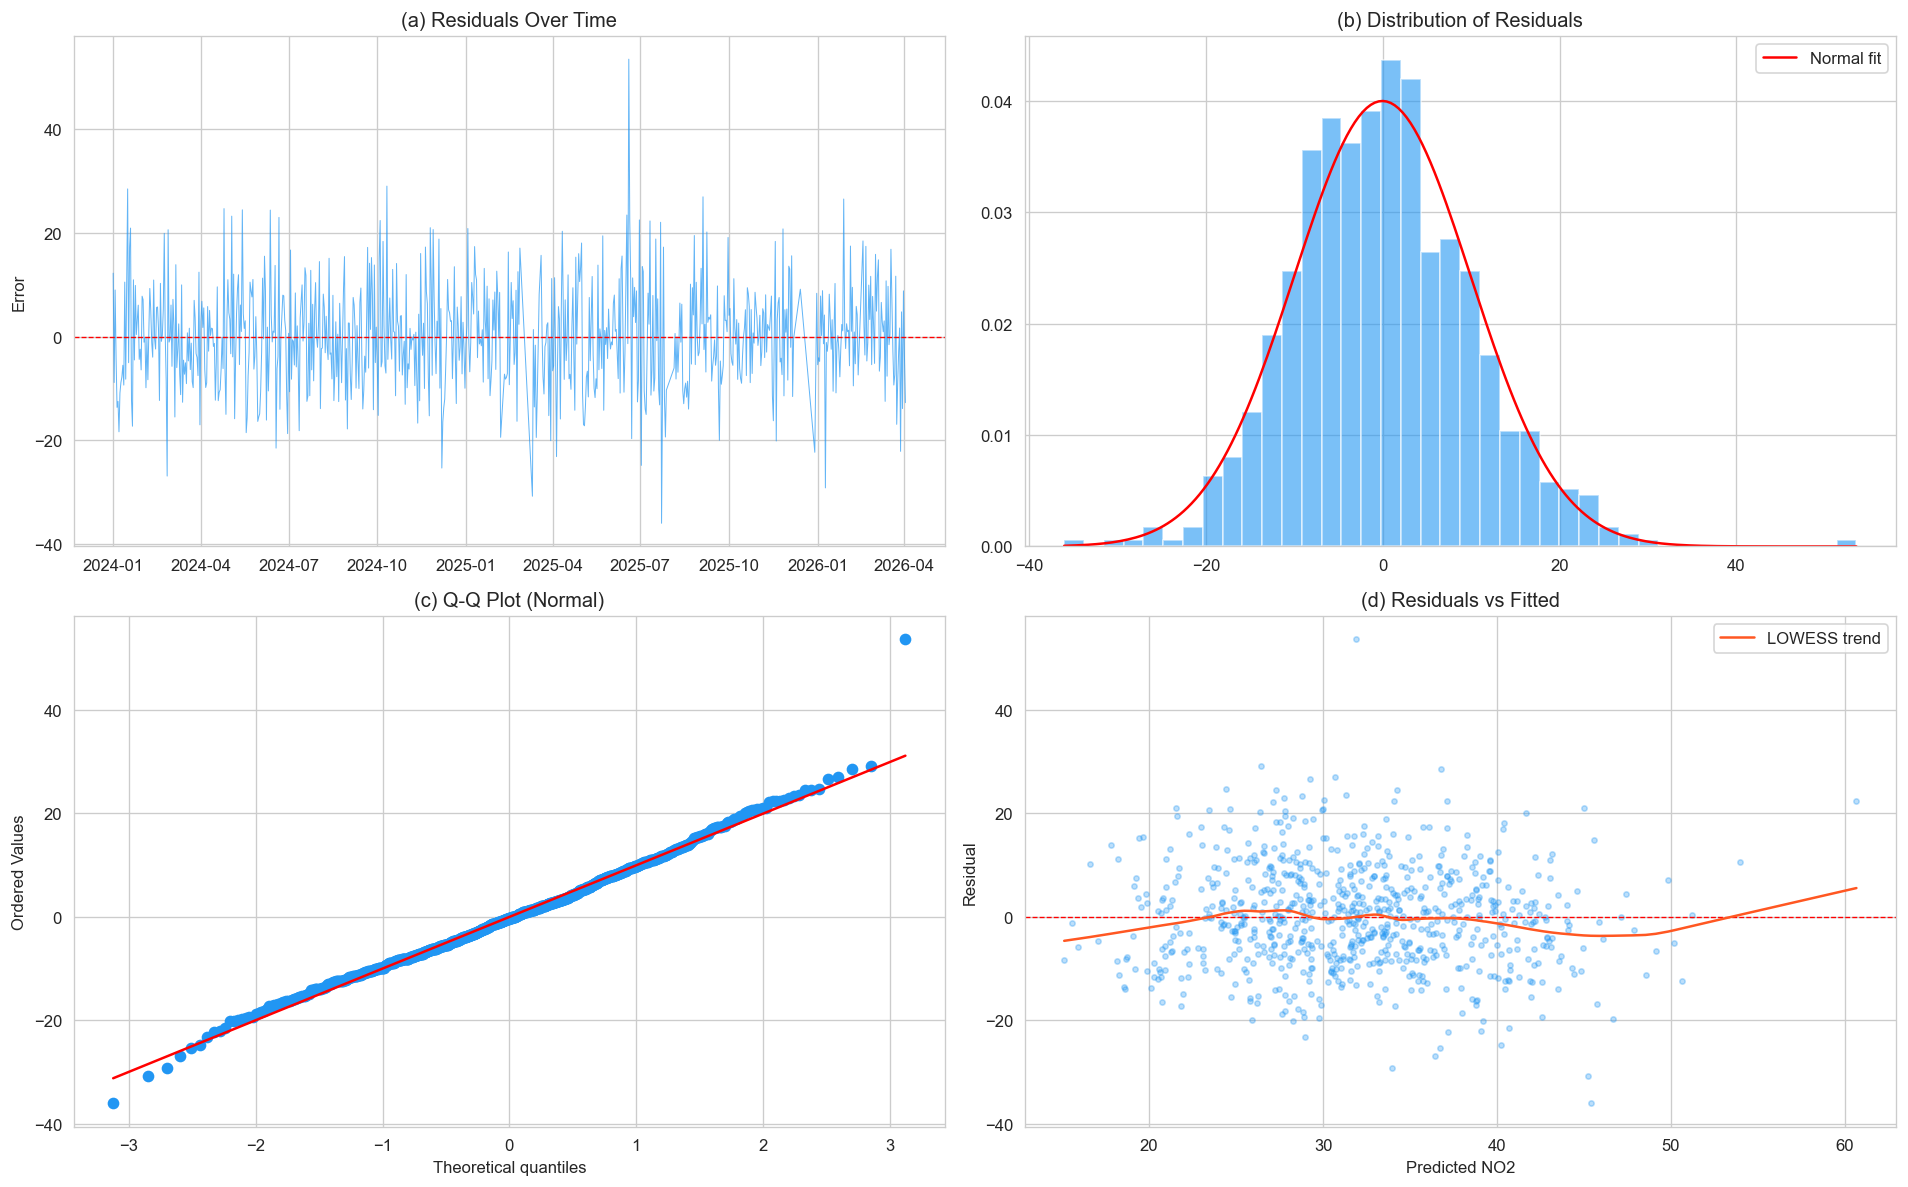

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (a) Residuals over time
axes[0, 0].plot(unseen.index, residuals, linewidth=0.6, color="#2196F3", alpha=0.7)
axes[0, 0].axhline(0, color="red", linewidth=0.8, linestyle="--")
axes[0, 0].set_title("(a) Residuals Over Time")
axes[0, 0].set_ylabel("Error")

# (b) Histogram + KDE
axes[0, 1].hist(residuals, bins=40, density=True, alpha=0.6, color="#2196F3", edgecolor="white")
x_range = np.linspace(residuals.min(), residuals.max(), 200)
axes[0, 1].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
                color="red", linewidth=1.5, label="Normal fit")
axes[0, 1].set_title("(b) Distribution of Residuals")
axes[0, 1].legend()

# (c) Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("(c) Q-Q Plot (Normal)")
axes[1, 0].get_lines()[0].set_color("#2196F3")
axes[1, 0].get_lines()[1].set_color("red")

# (d) Residuals vs Fitted
axes[1, 1].scatter(unseen["predicted"], residuals, alpha=0.3, s=10, color="#2196F3")
axes[1, 1].axhline(0, color="red", linewidth=0.8, linestyle="--")
# Lowess trend
from statsmodels.nonparametric.smoothers_lowess import lowess
smooth = lowess(residuals, unseen["predicted"].values, frac=0.3)
axes[1, 1].plot(smooth[:, 0], smooth[:, 1], color="#FF5722", linewidth=1.5, label="LOWESS trend")
axes[1, 1].set_title("(d) Residuals vs Fitted")
axes[1, 1].set_xlabel("Predicted NO2")
axes[1, 1].set_ylabel("Residual")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 2. Autocorrelation — Are Residuals White Noise?

If residuals have autocorrelation, the model is missing a pattern it should have captured. We check with ACF/PACF plots and the Ljung-Box test.

- **Ljung-Box H₀:** residuals are independently distributed (white noise)
- If p < 0.05 at any lag, the model is leaving predictable structure in the errors

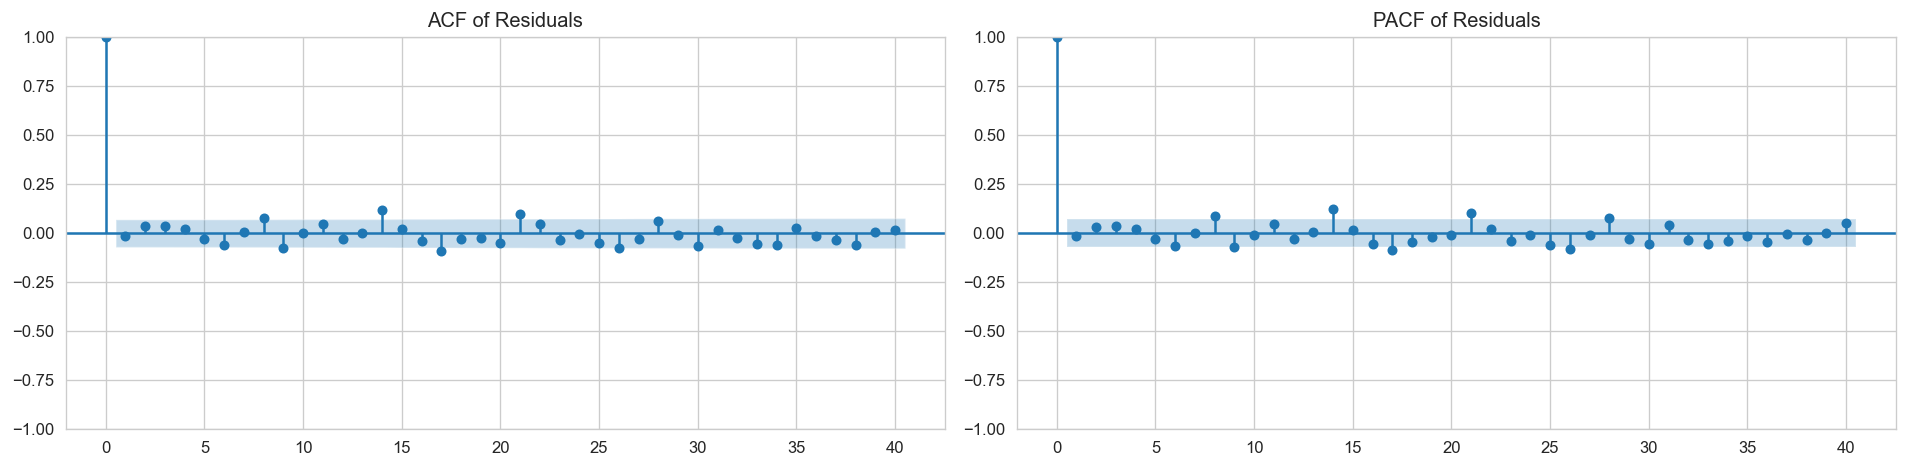

Ljung-Box Test:
  Lag      Statistic      p-value      White noise?
  ------------------------------------------------
  7        6.19           0.5180       Yes
  14       28.97          0.0106       NO — autocorrelation
  21       47.82          0.0007       NO — autocorrelation
  28       61.21          0.0003       NO — autocorrelation


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plot_acf(residuals, lags=40, ax=axes[0], alpha=0.05, title="ACF of Residuals")
plot_pacf(residuals, lags=40, ax=axes[1], alpha=0.05, title="PACF of Residuals", method="ywm")

plt.tight_layout()
plt.show()

# Ljung-Box test at multiple lags
lags_to_test = [7, 14, 21, 28]
lb_results = acorr_ljungbox(residuals, lags=lags_to_test, return_df=True)

print("Ljung-Box Test:")
print(f"  {'Lag':<8} {'Statistic':<14} {'p-value':<12} {'White noise?'}")
print(f"  {'-'*48}")
for lag in lags_to_test:
    stat = lb_results.loc[lag, "lb_stat"]
    pval = lb_results.loc[lag, "lb_pvalue"]
    result = "Yes" if pval > 0.05 else "NO — autocorrelation"
    print(f"  {lag:<8} {stat:<14.2f} {pval:<12.4f} {result}")

## 3. Normality — Are Residuals Normally Distributed?

ARIMA's prediction intervals assume normal residuals. If they're skewed or heavy-tailed, the confidence intervals are wrong.

- **Shapiro-Wilk** — most powerful normality test for moderate sample sizes
- **Jarque-Bera** — tests whether skewness and kurtosis match a normal distribution
- **D'Agostino-Pearson** — combines skewness and kurtosis tests

In [4]:
# Shapiro-Wilk (use first 500 — max for scipy)
sw_stat, sw_p = stats.shapiro(residuals[:500])

# Jarque-Bera
jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(residuals)

# D'Agostino-Pearson
da_stat, da_p = stats.normaltest(residuals)

print("Normality Tests:")
print(f"  {'Test':<25} {'Statistic':<14} {'p-value':<12} {'Normal?'}")
print(f"  {'-'*58}")
print(f"  {'Shapiro-Wilk':<25} {sw_stat:<14.4f} {sw_p:<12.4f} {'Yes' if sw_p > 0.05 else 'NO'}")
print(f"  {'Jarque-Bera':<25} {jb_stat:<14.2f} {jb_p:<12.4f} {'Yes' if jb_p > 0.05 else 'NO'}")
print(f"  {'D Agostino-Pearson':<25} {da_stat:<14.2f} {da_p:<12.4f} {'Yes' if da_p > 0.05 else 'NO'}")

print(f"\n  Skewness: {stats.skew(residuals):.3f} (0 = symmetric)")
print(f"  Excess Kurtosis: {stats.kurtosis(residuals):.3f} (0 = normal tails)")

Normality Tests:
  Test                      Statistic      p-value      Normal?
  ----------------------------------------------------------
  Shapiro-Wilk              0.9960         0.2414       Yes
  Jarque-Bera               43.15          0.0000       NO
  D Agostino-Pearson        27.30          0.0000       NO

  Skewness: 0.289 (0 = symmetric)
  Excess Kurtosis: 0.999 (0 = normal tails)


## 4. Homoscedasticity — Is the Variance Constant?

If error variance changes over time, the model's uncertainty estimates are unreliable. High NO2 periods might have larger errors than low NO2 periods.

- **ARCH test (Engle's)** — tests for autoregressive conditional heteroscedasticity in the residuals
- **Goldfeld-Quandt** — splits the data in half and compares variance between the two halves
- **Visual** — rolling standard deviation of residuals

Homoscedasticity Tests:
  Test                      Statistic      p-value      Constant variance?
  ------------------------------------------------------------
  ARCH (7 lags)             11.72          0.1102       Yes
  Levene (1st vs 2nd half)  0.98           0.3228       Yes

  First half std:  9.59
  Second half std: 10.35


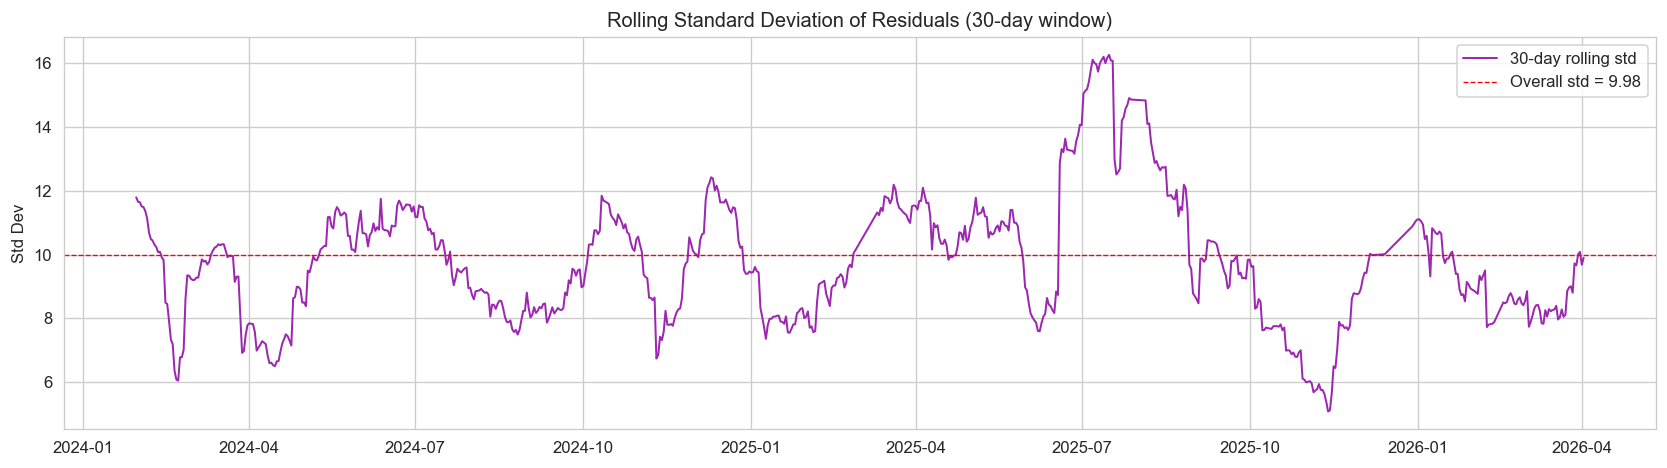

In [5]:
# ARCH test (Engle's LM test for heteroscedasticity)
arch_stat, arch_p, _, _ = het_arch(residuals, nlags=7)

# Goldfeld-Quandt: compare variance of first half vs second half
half = n // 2
first_half = residuals[:half]
second_half = residuals[half:]
gq_stat, gq_p = stats.levene(first_half, second_half)

print("Homoscedasticity Tests:")
print(f"  {'Test':<25} {'Statistic':<14} {'p-value':<12} {'Constant variance?'}")
print(f"  {'-'*60}")
print(f"  {'ARCH (7 lags)':<25} {arch_stat:<14.2f} {arch_p:<12.4f} {'Yes' if arch_p > 0.05 else 'NO — heteroscedastic'}")
print(f"  {'Levene (1st vs 2nd half)':<25} {gq_stat:<14.2f} {gq_p:<12.4f} {'Yes' if gq_p > 0.05 else 'NO — variance changed'}")

print(f"\n  First half std:  {first_half.std():.2f}")
print(f"  Second half std: {second_half.std():.2f}")

# Rolling std plot
fig, ax = plt.subplots(figsize=(14, 4))
rolling_std = pd.Series(residuals, index=unseen.index).rolling(30).std()
ax.plot(rolling_std.index, rolling_std, color="#9C27B0", linewidth=1.2, label="30-day rolling std")
ax.axhline(residuals.std(), color="red", linewidth=0.8, linestyle="--", label=f"Overall std = {residuals.std():.2f}")
ax.set_title("Rolling Standard Deviation of Residuals (30-day window)")
ax.set_ylabel("Std Dev")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Zero Mean — Is the Model Biased?

A non-zero mean residual indicates systematic over- or under-prediction. We test with a one-sample t-test.

- **H₀:** mean residual = 0 (no bias)
- **H₁:** mean residual ≠ 0 (model has systematic bias)

Zero Mean Test:
  Mean residual:    -0.0288
  95% CI for mean:  [-0.7300, 0.6724]
  t-statistic:      -0.080
  p-value:          0.9359
  Biased?           NO — mean consistent with zero


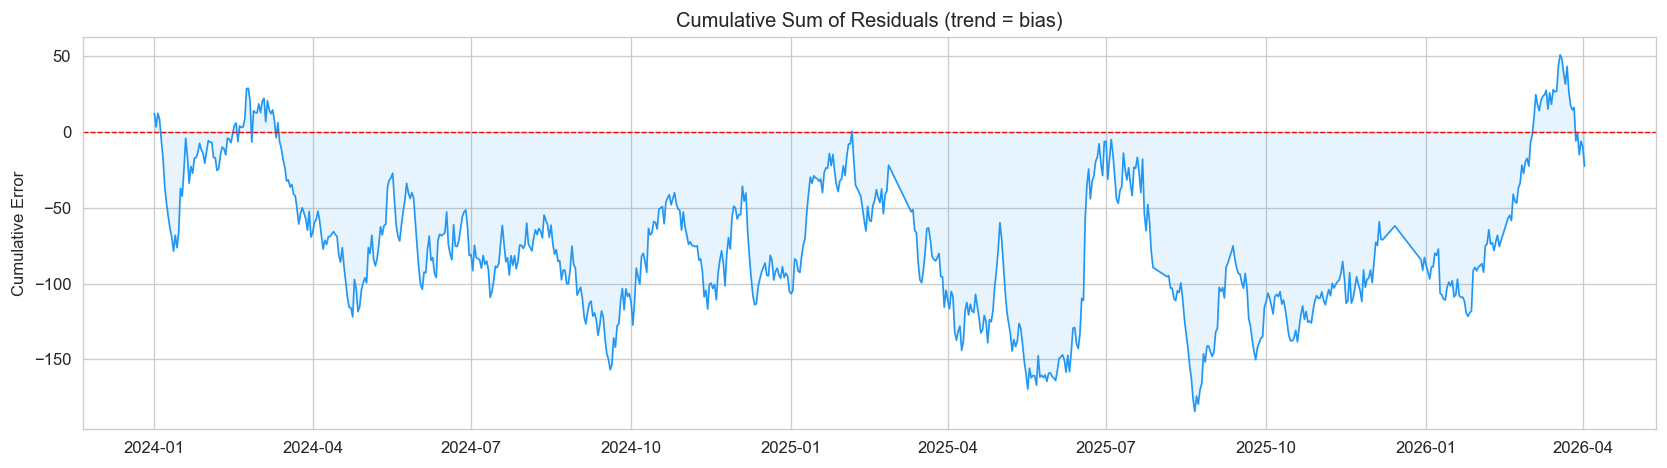

In [6]:
# One-sample t-test: is mean = 0?
t_stat, t_p = stats.ttest_1samp(residuals, 0)

# 95% CI for the mean
se = residuals.std() / np.sqrt(n)
ci_low = residuals.mean() - 1.96 * se
ci_high = residuals.mean() + 1.96 * se

print("Zero Mean Test:")
print(f"  Mean residual:    {residuals.mean():.4f}")
print(f"  95% CI for mean:  [{ci_low:.4f}, {ci_high:.4f}]")
print(f"  t-statistic:      {t_stat:.3f}")
print(f"  p-value:          {t_p:.4f}")
print(f"  Biased?           {'NO — mean consistent with zero' if t_p > 0.05 else 'YES — systematic bias detected'}")

# Cumulative residual plot — should wander around zero, not trend
fig, ax = plt.subplots(figsize=(14, 4))
cumsum = np.cumsum(residuals)
ax.plot(unseen.index, cumsum, color="#2196F3", linewidth=1)
ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
ax.fill_between(unseen.index, cumsum, 0, alpha=0.1, color="#2196F3")
ax.set_title("Cumulative Sum of Residuals (trend = bias)")
ax.set_ylabel("Cumulative Error")
plt.tight_layout()
plt.show()

## 6. Summary

All four ARIMA assumptions tested on 778 days of unseen prediction errors.

In [7]:
print("=" * 65)
print("RESIDUAL DIAGNOSTICS SUMMARY")
print("=" * 65)

print(f"\n{'Assumption':<30} {'Test':<25} {'p-value':<12} {'Holds?'}")
print(f"{'-'*75}")

# White noise
lb_worst = acorr_ljungbox(residuals, lags=[28], return_df=True)
lb_p = lb_worst.iloc[0]["lb_pvalue"]
print(f"{'White noise':<30} {'Ljung-Box (lag=28)':<25} {lb_p:<12.4f} {'YES' if lb_p > 0.05 else 'NO'}")

# Normality
print(f"{'Normality':<30} {'Jarque-Bera':<25} {jb_p:<12.4f} {'YES' if jb_p > 0.05 else 'NO'}")

# Constant variance
print(f"{'Homoscedasticity':<30} {'ARCH (7 lags)':<25} {arch_p:<12.4f} {'YES' if arch_p > 0.05 else 'NO'}")

# Zero mean
print(f"{'Zero mean (no bias)':<30} {'1-sample t-test':<25} {t_p:<12.4f} {'YES' if t_p > 0.05 else 'NO'}")

# Verdict
assumptions = [lb_p > 0.05, jb_p > 0.05, arch_p > 0.05, t_p > 0.05]
passed = sum(assumptions)

print(f"\n{'='*65}")
print(f"Assumptions holding: {passed}/4")

if passed == 4:
    print("VERDICT: All assumptions hold — model is structurally valid")
elif passed == 3:
    print("VERDICT: Minor violation — model is largely valid, CI may be slightly off")
elif passed == 2:
    print("VERDICT: Moderate violations — predictions may be reliable but CI are suspect")
else:
    print("VERDICT: Major violations — model structure may be inadequate")
print(f"{'='*65}")

RESIDUAL DIAGNOSTICS SUMMARY

Assumption                     Test                      p-value      Holds?
---------------------------------------------------------------------------
White noise                    Ljung-Box (lag=28)        0.0003       NO
Normality                      Jarque-Bera               0.0000       NO
Homoscedasticity               ARCH (7 lags)             0.1102       YES
Zero mean (no bias)            1-sample t-test           0.9359       YES

Assumptions holding: 2/4
VERDICT: Moderate violations — predictions may be reliable but CI are suspect
